# CS466 Final Project: Nussinov Algorithm for RNA Secondary Structure Prediction

**Author**: Yuhan Cui (yuhanc10)  
**Course**: CS466  

## 1. Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import tracemalloc
from collections import defaultdict

from datasets import load_dataset
from scipy.optimize import curve_fit

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

c:\Users\cyh\anaconda3\envs\cs512\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Loading the ArchiveII Dataset

In [2]:
# Load ArchiveII dataset from Hugging Face
dataset = load_dataset("multimolecule/archiveii", split="test")

print(f"Total samples: {len(dataset)}")
print(f"Dataset fields: {dataset.column_names}")
print(f"\n--- First sample example ---")
print(f"ID:     {dataset[0]['id']}")
print(f"Family: {dataset[0]['family']}")
print(f"Sequence length: {len(dataset[0]['sequence'])}")
print(f"Sequence:   {dataset[0]['sequence'][:80]}...")
print(f"Structure:   {dataset[0]['secondary_structure'][:80]}...")

Total samples: 3975
Dataset fields: ['id', 'sequence', 'secondary_structure', 'family']

--- First sample example ---
ID:     16S_rRNA-A.fulgidus
Family: 16S_rRNA
Sequence length: 1492
Sequence:   AUUCUGGUUGAUCCUGCCAGAGGCCGCUGCUAUCCGGCUGGGACUAAGCCAUGCGAGUCAAGGGGCUUGUAUCCCUUCGG...
Structure:   ...(((((...(((.))))).((((((((((.((((((((((.....(((.(((..(((..((.(((((((((((....)...


RNA Family Statistics:
Family                  Count      Min      Max Avg Length
------------------------------------------------------------
16S_rRNA                  110       73     1995      611.6
23S_rRNA                   35      242     2968      819.3
5S_rRNA                  1283      102      135      118.7
RNaseP                    454      120      486      332.2
SRP                       928       28      533      183.9
group_II_intron            11      619      780      716.5
group_I_intron             98      210      736      426.4
tRNA                      557       54       93       77.1
telomerase                 37      382      559      444.6
tmRNA                     462      102      437      366.0


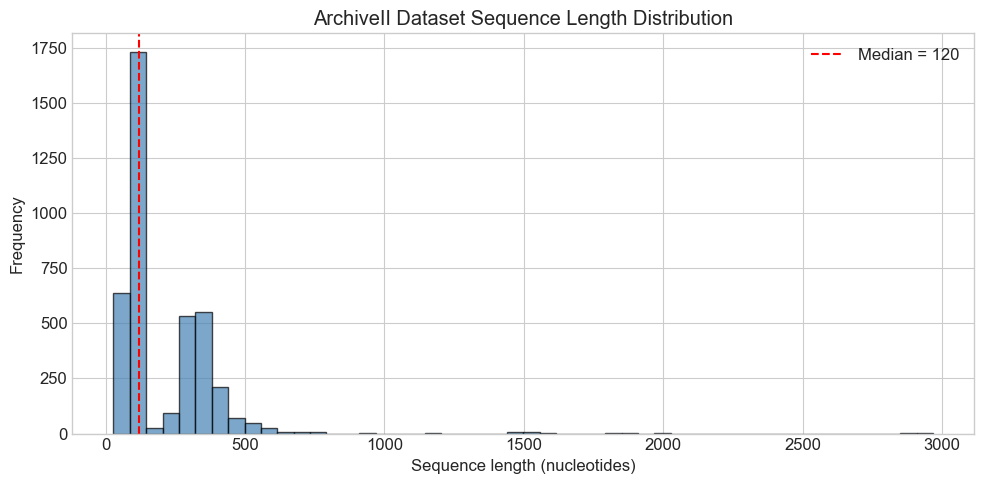

In [3]:
family_stats = defaultdict(list)
for sample in dataset:
    family_stats[sample['family']].append(len(sample['sequence']))

print("RNA Family Statistics:")
print(f"{'Family':<20} {'Count':>8} {'Min':>8} {'Max':>8} {'Avg Length':>10}")
print("-" * 60)
for family, lengths in sorted(family_stats.items()):
    print(f"{family:<20} {len(lengths):>8} {min(lengths):>8} {max(lengths):>8} {np.mean(lengths):>10.1f}")

all_lengths = [len(s['sequence']) for s in dataset]
plt.figure(figsize=(10, 5))
plt.hist(all_lengths, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Sequence length (nucleotides)')
plt.ylabel('Frequency')
plt.title('ArchiveII Dataset Sequence Length Distribution')
plt.axvline(np.median(all_lengths), color='red', linestyle='--', label=f'Median = {np.median(all_lengths):.0f}')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Nussinov Algorithm Implementation

In [4]:
def is_valid_pair(base_i, base_j):
    """
    Check if two bases can form a valid pair (A-U, G-C, G-U)
    """
    pair = (base_i.upper(), base_j.upper())
    valid_pairs = {
        ('A', 'U'), ('U', 'A'),
        ('G', 'C'), ('C', 'G')
    }
    return pair in valid_pairs

### 3.1 DP Filling Phase

In [5]:
def nussinov_fill(sequence):
    n = len(sequence)
    dp = np.zeros((n, n), dtype=np.int32)
    
    for l in range(1, n):
        for i in range(n - l):
            j = i + l
            best = dp[i + 1][j]
            best = max(best, dp[i][j - 1])
            if is_valid_pair(sequence[i], sequence[j]):
                pair_score = dp[i + 1][j - 1] + 1 if l > 1 else 1
                best = max(best, pair_score)
            for k in range(i, j):
                best = max(best, dp[i][k] + dp[k + 1][j])
            
            dp[i][j] = best
    
    return dp

### 3.2 Traceback Phase

In [6]:
def nussinov_traceback(dp, sequence):
    n = len(sequence)
    structure = ['.'] * n
    pairs = []
    
    stack = [(0, n - 1)]
    
    while stack:
        i, j = stack.pop()
        
        if i >= j:
            continue
        if dp[i][j] == dp[i + 1][j]:
            stack.append((i + 1, j))

        elif dp[i][j] == dp[i][j - 1]:
            stack.append((i, j - 1))
        
        elif is_valid_pair(sequence[i], sequence[j]) and dp[i][j] == dp[i + 1][j - 1] + 1:
            pairs.append((i, j))
            structure[i] = '('
            structure[j] = ')'
            stack.append((i + 1, j - 1))

        else:
            for k in range(i, j):
                if dp[i][j] == dp[i][k] + dp[k + 1][j]:
                    stack.append((i, k))
                    stack.append((k + 1, j))
                    break
    
    return ''.join(structure), pairs

In [7]:
def nussinov_predict(sequence):
    dp = nussinov_fill(sequence)
    structure, pairs = nussinov_traceback(dp, sequence)
    score = int(dp[0][len(sequence) - 1])
    return structure, pairs, score

### 3.3 Algorithm Testing

Test sequence: GGGAAAUCC
Sequence length: 9

Sequence: GGGAAAUCC
Structure: .((..()))
Maximum pairs: 3
Pair list: [(1, 8), (2, 7), (5, 6)]



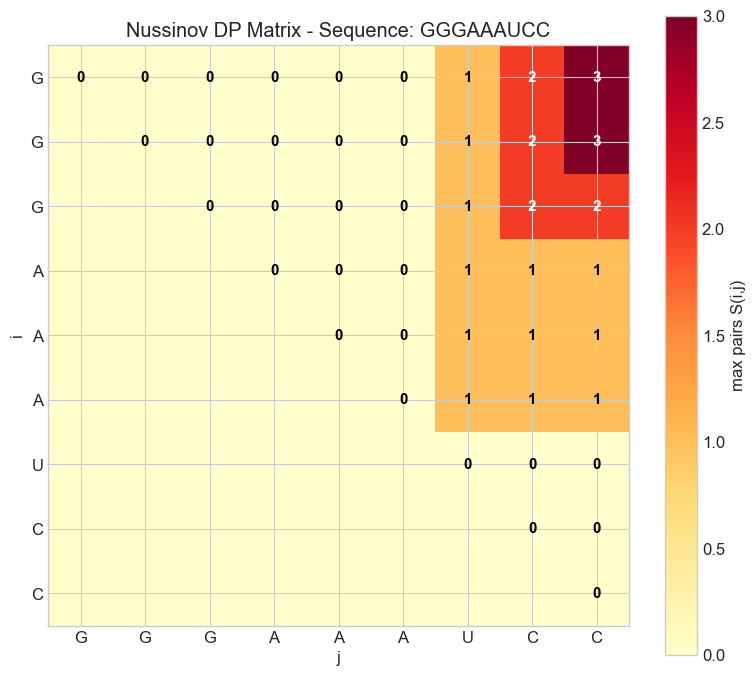

In [8]:
test_seq = "GGGAAAUCC"
print(f"Test sequence: {test_seq}")
print(f"Sequence length: {len(test_seq)}")
print()

dp_test = nussinov_fill(test_seq)
structure_test, pairs_test = nussinov_traceback(dp_test, test_seq)
score_test = dp_test[0][len(test_seq) - 1]

print(f"Sequence: {test_seq}")
print(f"Structure: {structure_test}")
print(f"Maximum pairs: {score_test}")
print(f"Pair list: {pairs_test}")
print()

# Visualize DP matrix
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(dp_test, cmap='YlOrRd', interpolation='nearest')
ax.set_xticks(range(len(test_seq)))
ax.set_yticks(range(len(test_seq)))
ax.set_xticklabels(list(test_seq))
ax.set_yticklabels(list(test_seq))
ax.set_xlabel('j')
ax.set_ylabel('i')
ax.set_title(f'Nussinov DP Matrix - Sequence: {test_seq}')

for i in range(len(test_seq)):
    for j in range(len(test_seq)):
        if j >= i:
            ax.text(j, i, str(dp_test[i][j]), ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if dp_test[i][j] > score_test / 2 else 'black')

plt.colorbar(im, label='max pairs S(i,j)')
plt.tight_layout()
plt.show()

### 3.4 Testing with Real RNA Sequences from ArchiveII Dataset

In [9]:
short_samples = [(i, len(s['sequence'])) for i, s in enumerate(dataset) if len(s['sequence']) < 80]
short_samples.sort(key=lambda x: x[1])

# Select a moderately short sequence
idx = short_samples[len(short_samples) // 2][0]
sample = dataset[idx]

seq = sample['sequence']
true_structure = sample['secondary_structure']

print(f"Sample ID: {sample['id']}")
print(f"RNA Family: {sample['family']}")
print(f"Sequence length: {len(seq)}")
print()

pred_structure, pred_pairs, pred_score = nussinov_predict(seq)

print(f"Sequence:     {seq}")
print(f"True structure: {true_structure}")
print(f"Predicted structure: {pred_structure}")
print(f"Predicted pairs: {pred_score}")

Sample ID: tRNA-tdbR00000064-Mycoplasma_capricolum-2095-Phe-GAA
RNA Family: tRNA
Sequence length: 76

Sequence:     GGUCGUGUAGCUCAGUCGGUAGAGCAGCAGACUGAAGCUCUGCGUGUCGGCGGUUCAAUUCCGUCCACGACCACCA
True structure: (((((((..((((........)))).(((((.......))))).....(((((.......))))))))))))....
Predicted structure: ((.()((((())(.((()(()((()(.(((.)))((())(.())).)(((()(..)(())))))))))))).))).
Predicted pairs: 33


## 4. Synthetic Dataset Generation and Testing

In [10]:
import random

def generate_perfect_hairpin(stem_length=5, loop_length=4):
    left_stem = ''.join(random.choice(['G']) for _ in range(stem_length))
    loop = ''.join(random.choice(['A', 'U']) for _ in range(loop_length))
    right_stem = ''.join(['C'] * stem_length)
    
    sequence = left_stem + loop + right_stem
    structure = '(' * stem_length + '.' * loop_length + ')' * stem_length
    
    return sequence, structure

def generate_two_hairpins(stem1_len=4, loop1_len=3, stem2_len=4, loop2_len=3):
    left1 = ''.join(['G'] * stem1_len)
    loop1 = ''.join(['A'] * loop1_len)
    right1 = ''.join(['C'] * stem1_len)
    
    spacer = 'UU'
    
    left2 = ''.join(['G'] * stem2_len)
    loop2 = ''.join(['A'] * loop2_len)
    right2 = ''.join(['C'] * stem2_len)
    
    sequence = left1 + loop1 + right1 + spacer + left2 + loop2 + right2
    structure = ('(' * stem1_len + '.' * loop1_len + ')' * stem1_len + 
                 '..' +
                 '(' * stem2_len + '.' * loop2_len + ')' * stem2_len)
    
    return sequence, structure

def generate_bulged_hairpin(stem_len=6, loop_len=4, bulge_pos=2):
    left_stem = ['G'] * stem_len
    right_stem = ['C'] * stem_len
    left_stem.insert(bulge_pos, 'A')
    loop = ['A', 'U'] * (loop_len // 2)
    sequence = ''.join(left_stem + loop + right_stem)
    left_struct = ['('] * (stem_len + 1)
    left_struct[bulge_pos] = '.'
    structure = ''.join(left_struct) + '.' * loop_len + ')' * stem_len
    
    return sequence, structure

random.seed(42)
synthetic_tests = []

# Test 1: Perfect hairpins of various sizes
for stem_len in [3, 5, 7, 10]:
    for loop_len in [3, 5]:
        seq, struct = generate_perfect_hairpin(stem_len, loop_len)
        synthetic_tests.append({
            'name': f'PerfectHairpin_stem{stem_len}_loop{loop_len}',
            'sequence': seq,
            'true_structure': struct,
            'type': 'perfect_hairpin'
        })

# Test 2: Two hairpins
for s1, l1, s2, l2 in [(3, 3, 3, 3), (4, 4, 5, 3), (5, 3, 4, 4)]:
    seq, struct = generate_two_hairpins(s1, l1, s2, l2)
    synthetic_tests.append({
        'name': f'TwoHairpins_s{s1}l{l1}_s{s2}l{l2}',
        'sequence': seq,
        'true_structure': struct,
        'type': 'two_hairpins'
    })

# Test 3: Bulged hairpins
for stem_len in [5, 7]:
    for bulge_pos in [1, 3]:
        seq, struct = generate_bulged_hairpin(stem_len, 4, bulge_pos)
        synthetic_tests.append({
            'name': f'BulgedHairpin_stem{stem_len}_bulge{bulge_pos}',
            'sequence': seq,
            'true_structure': struct,
            'type': 'bulged_hairpin'
        })

print(f"Generated {len(synthetic_tests)} synthetic test cases")
print("\n--- Sample synthetic sequences ---")
for i, test in enumerate(synthetic_tests[:5]):
    print(f"{test['name']}:")
    print(f"  Sequence: {test['sequence']}")
    print(f"  Structure: {test['true_structure']}")
    print()

Generated 15 synthetic test cases

--- Sample synthetic sequences ---
PerfectHairpin_stem3_loop3:
  Sequence: GGGAAACCC
  Structure: (((...)))

PerfectHairpin_stem3_loop5:
  Sequence: GGGAAAAACCC
  Structure: (((.....)))

PerfectHairpin_stem5_loop3:
  Sequence: GGGGGUAACCCCC
  Structure: (((((...)))))

PerfectHairpin_stem5_loop5:
  Sequence: GGGGGUAAUACCCCC
  Structure: (((((.....)))))

PerfectHairpin_stem7_loop3:
  Sequence: GGGGGGGAUUCCCCCCC
  Structure: (((((((...)))))))



In [11]:
def parse_dot_bracket(structure):
    pairs = set()
    stack = []
    for idx, ch in enumerate(structure):
        if ch == '(':
            stack.append(idx)
        elif ch == ')':
            if stack:
                i = stack.pop()
                pairs.add((i, idx))
    return pairs


def evaluate_prediction(true_structure, pred_structure):
    true_pairs = parse_dot_bracket(true_structure)
    pred_pairs = parse_dot_bracket(pred_structure)
    
    tp = len(true_pairs & pred_pairs)
    fp = len(pred_pairs - true_pairs)
    fn = len(true_pairs - pred_pairs)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = (2 * precision * sensitivity / (precision + sensitivity)
          if (precision + sensitivity) > 0 else 0.0)
    
    return {
        'sensitivity': sensitivity,
        'precision': precision,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'true_pairs': len(true_pairs),
        'pred_pairs': len(pred_pairs)
    }

## 5. Evaluation


### 5.1 Synthetic Dataset

In [12]:
synthetic_results = []

for test in synthetic_tests:
    pred_struct, pred_pairs, score = nussinov_predict(test['sequence'])
    metrics = evaluate_prediction(test['true_structure'], pred_struct)
    
    synthetic_results.append({
        'name': test['name'],
        'type': test['type'],
        'sequence': test['sequence'],
        'true_structure': test['true_structure'],
        'predicted_structure': pred_struct,
        'length': len(test['sequence']),
        **metrics
    })

# Calculate accuracy statistics
synthetic_sens = [r['sensitivity'] for r in synthetic_results]
synthetic_prec = [r['precision'] for r in synthetic_results]
synthetic_f1 = [r['f1'] for r in synthetic_results]

print("="*70)
print("Nussinov Performance on Synthetic Dataset")
print("="*70)
print(f"Total synthetic tests: {len(synthetic_results)}")
print(f"")
print(f"Sensitivity: Mean={np.mean(synthetic_sens):.4f}, Median={np.median(synthetic_sens):.4f}")
print(f"Precision:   Mean={np.mean(synthetic_prec):.4f}, Median={np.median(synthetic_prec):.4f}")
print(f"F1 Score:    Mean={np.mean(synthetic_f1):.4f}, Median={np.median(synthetic_f1):.4f}")
print("="*70)

# Group by structure type
print("\n--- Performance by Structure Type ---")
type_results = defaultdict(list)
for r in synthetic_results:
    type_results[r['type']].append(r)

for struct_type in sorted(type_results.keys()):
    tr = type_results[struct_type]
    avg_sens = np.mean([x['sensitivity'] for x in tr])
    avg_prec = np.mean([x['precision'] for x in tr])
    avg_f1 = np.mean([x['f1'] for x in tr])
    print(f"{struct_type:<20}: Sens={avg_sens:.4f}, Prec={avg_prec:.4f}, F1={avg_f1:.4f}")

# Show detailed results for a few examples
print("\n--- Detailed Results (First 3) ---")
for r in synthetic_results[:3]:
    print(f"\n{r['name']}:")
    print(f"  Sequence:  {r['sequence']}")
    print(f"  True:      {r['true_structure']}")
    print(f"  Predicted: {r['predicted_structure']}")
    print(f"  F1 Score:  {r['f1']:.4f}")

Nussinov Performance on Synthetic Dataset
Total synthetic tests: 15

Sensitivity: Mean=0.8148, Median=1.0000
Precision:   Mean=0.6831, Median=0.7778
F1 Score:    Mean=0.7406, Median=0.8750

--- Performance by Structure Type ---
bulged_hairpin      : Sens=1.0000, Prec=0.7460, F1=0.8542
perfect_hairpin     : Sens=1.0000, Prec=0.8800, F1=0.9338
two_hairpins        : Sens=0.0741, Prec=0.0741, F1=0.0741

--- Detailed Results (First 3) ---

PerfectHairpin_stem3_loop3:
  Sequence:  GGGAAACCC
  True:      (((...)))
  Predicted: (((...)))
  F1 Score:  1.0000

PerfectHairpin_stem3_loop5:
  Sequence:  GGGAAAAACCC
  True:      (((.....)))
  Predicted: (((.....)))
  F1 Score:  1.0000

PerfectHairpin_stem5_loop3:
  Sequence:  GGGGGUAACCCCC
  True:      (((((...)))))
  Predicted: (((((().)))))
  F1 Score:  0.9091


### 5.2 ArchiveII Dataset

In [26]:
MAX_LENGTH = 500

# Filter processable sequences
eval_samples = [(i, s) for i, s in enumerate(dataset) if len(s['sequence']) <= MAX_LENGTH]
print(f"Total samples: {len(dataset)}")
print(f"Samples with length ≤ {MAX_LENGTH}: {len(eval_samples)}")
print()

results = []
total = len(eval_samples)

for count, (idx, sample) in enumerate(eval_samples):
    seq = sample['sequence']
    true_struct = sample['secondary_structure']
    family = sample['family']
    
    pred_struct, _, score = nussinov_predict(seq)
    metrics = evaluate_prediction(true_struct, pred_struct)
    metrics['family'] = family
    metrics['length'] = len(seq)
    metrics['id'] = sample['id']
    results.append(metrics)
    
    if (count + 1) % 100 == 0 or count == 0:
        print(f"Progress: {count + 1}/{total} ({(count + 1) / total * 100:.1f}%)")

print(f"\nEvaluation complete! Processed {len(results)} sequences.")

Total samples: 3975
Samples with length ≤ 500: 3854

Progress: 1/3854 (0.0%)
Progress: 100/3854 (2.6%)
Progress: 200/3854 (5.2%)
Progress: 300/3854 (7.8%)
Progress: 400/3854 (10.4%)
Progress: 500/3854 (13.0%)
Progress: 600/3854 (15.6%)
Progress: 700/3854 (18.2%)
Progress: 800/3854 (20.8%)
Progress: 900/3854 (23.4%)
Progress: 1000/3854 (25.9%)
Progress: 1100/3854 (28.5%)
Progress: 1200/3854 (31.1%)
Progress: 1300/3854 (33.7%)
Progress: 1400/3854 (36.3%)
Progress: 1500/3854 (38.9%)
Progress: 1600/3854 (41.5%)
Progress: 1700/3854 (44.1%)
Progress: 1800/3854 (46.7%)
Progress: 1900/3854 (49.3%)
Progress: 2000/3854 (51.9%)
Progress: 2100/3854 (54.5%)
Progress: 2200/3854 (57.1%)
Progress: 2300/3854 (59.7%)
Progress: 2400/3854 (62.3%)
Progress: 2500/3854 (64.9%)
Progress: 2600/3854 (67.5%)
Progress: 2700/3854 (70.1%)
Progress: 2800/3854 (72.7%)
Progress: 2900/3854 (75.2%)
Progress: 3000/3854 (77.8%)
Progress: 3100/3854 (80.4%)
Progress: 3200/3854 (83.0%)
Progress: 3300/3854 (85.6%)
Progress: 3

In [27]:
sensitivities = [r['sensitivity'] for r in results]
precisions = [r['precision'] for r in results]
f1_scores = [r['f1'] for r in results]

print("="*60)
print("Overall Evaluation Results")
print("="*60)
print(f"Evaluated samples: {len(results)}")
print(f"")
print(f"Sensitivity:")
print(f"  Mean: {np.mean(sensitivities):.4f}")
print(f"  Median: {np.median(sensitivities):.4f}")
print(f"  Std Dev: {np.std(sensitivities):.4f}")
print(f"")
print(f"Precision:")
print(f"  Mean: {np.mean(precisions):.4f}")
print(f"  Median: {np.median(precisions):.4f}")
print(f"  Std Dev: {np.std(precisions):.4f}")
print(f"")
print(f"F1 Score:")
print(f"  Mean: {np.mean(f1_scores):.4f}")
print(f"  Median: {np.median(f1_scores):.4f}")
print(f"  Std Dev: {np.std(f1_scores):.4f}")
print("="*60)

Overall Evaluation Results
Evaluated samples: 3854

Sensitivity:
  Mean: 0.0487
  Median: 0.0098
  Std Dev: 0.0802

Precision:
  Mean: 0.0308
  Median: 0.0063
  Std Dev: 0.0490

F1 Score:
  Mean: 0.0375
  Median: 0.0076
  Std Dev: 0.0601


## 6. Improved Nussinov Algorithm

In [ ]:
def nussinov_improved_fill(sequence, min_loop_length=3, use_distance_penalty=False):
    n = len(sequence)
    dp = np.zeros((n, n), dtype=np.float32)
    
    for l in range(1, n):
        for i in range(n - l):
            j = i + l
            best = dp[i + 1][j]
            best = max(best, dp[i][j - 1])
            if is_valid_pair(sequence[i], sequence[j]):
                if l > min_loop_length:
                    base_score = 1.0
                    if use_distance_penalty:
                        if l <= min_loop_length + 2:
                            base_score = 0.5
                    pair_score = dp[i + 1][j - 1] + base_score if l > 1 else base_score
                    best = max(best, pair_score)
            for k in range(i, j):
                best = max(best, dp[i][k] + dp[k + 1][j])
            dp[i][j] = best
    
    return dp

def nussinov_improved_traceback(dp, sequence, min_loop_length=3):
    n = len(sequence)
    structure = ['.'] * n
    pairs = []
    
    stack = [(0, n - 1)]
    
    while stack:
        i, j = stack.pop()
        
        if i >= j:
            continue
        if abs(dp[i][j] - dp[i + 1][j]) < 0.001:
            stack.append((i + 1, j))
        elif abs(dp[i][j] - dp[i][j - 1]) < 0.001:
            stack.append((i, j - 1))
        elif (j - i) > min_loop_length and is_valid_pair(sequence[i], sequence[j]):
            expected_score = dp[i + 1][j - 1] + 1.0
            if abs(dp[i][j] - expected_score) < 0.001 or dp[i][j] >= expected_score - 0.5:
                pairs.append((i, j))
                structure[i] = '('
                structure[j] = ')'
                stack.append((i + 1, j - 1))
        else:
            for k in range(i, j):
                if abs(dp[i][j] - (dp[i][k] + dp[k + 1][j])) < 0.001:
                    stack.append((i, k))
                    stack.append((k + 1, j))
                    break
    
    return ''.join(structure), pairs

def nussinov_improved_predict(sequence, min_loop_length=3):
    dp = nussinov_improved_fill(sequence, min_loop_length)
    structure, pairs = nussinov_improved_traceback(dp, sequence, min_loop_length)
    score = float(dp[0][len(sequence) - 1])
    return structure, pairs, score

In [ ]:
# Compare original vs improved on synthetic dataset
print("Comparing Original vs Improved Nussinov on Synthetic Dataset")
print("="*70)

orig_f1_scores = []
orig_sens_scores = []
orig_prec_scores = []
improved_f1_scores = []
improved_sens_scores = []
improved_prec_scores = []

for test in synthetic_tests:
    # Original
    pred_orig, _, _ = nussinov_predict(test['sequence'])
    metrics_orig = evaluate_prediction(test['true_structure'], pred_orig)
    orig_f1_scores.append(metrics_orig['f1'])
    orig_sens_scores.append(metrics_orig['sensitivity'])
    orig_prec_scores.append(metrics_orig['precision'])
    
    # Improved with min_loop=3
    pred_improved, _, _ = nussinov_improved_predict(test['sequence'], min_loop_length=3)
    metrics_improved = evaluate_prediction(test['true_structure'], pred_improved)
    improved_f1_scores.append(metrics_improved['f1'])
    improved_sens_scores.append(metrics_improved['sensitivity'])
    improved_prec_scores.append(metrics_improved['precision'])

print(f"Synthetic Dataset Results:")
print(f"  Original Nussinov:   Mean F1 = {np.mean(orig_f1_scores):.4f}, Sens = {np.mean(orig_sens_scores):.4f}, Prec = {np.mean(orig_prec_scores):.4f}")
print(f"  Improved (loop=3):   Mean F1 = {np.mean(improved_f1_scores):.4f}, Sens = {np.mean(improved_sens_scores):.4f}, Prec = {np.mean(improved_prec_scores):.4f}")
print(f"  Improvement:         {(np.mean(improved_f1_scores)/np.mean(orig_f1_scores) - 1)*100:.1f}%")
print()

# Compare on a sample of ArchiveII (to save time)
sample_size = 200
sample_indices = np.random.choice(len(results), sample_size, replace=False)

print(f"Comparing on {sample_size} ArchiveII samples...")
archive_orig_f1 = []
archive_orig_sens = []
archive_orig_prec = []
archive_improved_f1 = []
archive_improved_sens = []
archive_improved_prec = []

for idx in sample_indices:
    r = results[idx]
    sample = [s for s in dataset if s['id'] == r['id']][0]
    seq = sample['sequence']
    true_struct = sample['secondary_structure']
    
    # Original
    pred_orig, _, _ = nussinov_predict(seq)
    metrics_orig = evaluate_prediction(true_struct, pred_orig)
    archive_orig_f1.append(metrics_orig['f1'])
    archive_orig_sens.append(metrics_orig['sensitivity'])
    archive_orig_prec.append(metrics_orig['precision'])
    
    # Improved
    pred_imp, _, _ = nussinov_improved_predict(seq, min_loop_length=3)
    metrics_imp = evaluate_prediction(true_struct, pred_imp)
    archive_improved_f1.append(metrics_imp['f1'])
    archive_improved_sens.append(metrics_imp['sensitivity'])
    archive_improved_prec.append(metrics_imp['precision'])

print(f"\nArchiveII Sample Results (n={sample_size}):")
print(f"  Original Nussinov:   Mean F1 = {np.mean(archive_orig_f1):.4f}, Sens = {np.mean(archive_orig_sens):.4f}, Prec = {np.mean(archive_orig_prec):.4f}")
print(f"  Improved (loop=3):   Mean F1 = {np.mean(archive_improved_f1):.4f}, Sens = {np.mean(archive_improved_sens):.4f}, Prec = {np.mean(archive_improved_prec):.4f}")
improvement = (np.mean(archive_improved_f1)/np.mean(archive_orig_f1) - 1)*100 if np.mean(archive_orig_f1) > 0 else 0
print(f"  Improvement:         {improvement:.1f}%")
print("="*70)



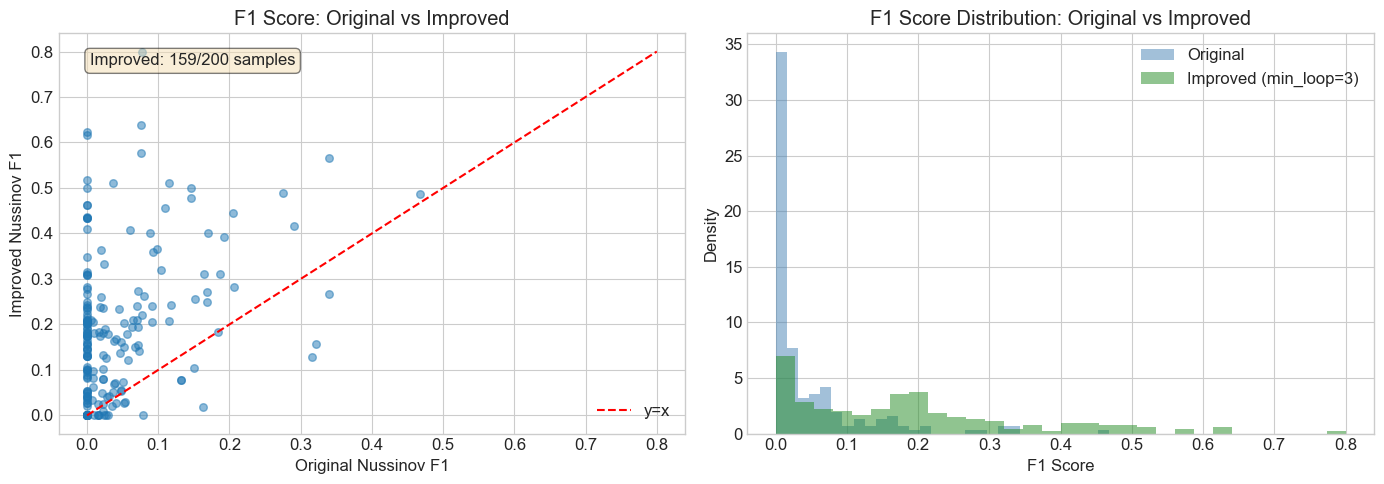


--- Detailed Comparison ---
Metric                   Original     Improved       Change
------------------------------------------------------------
Mean F1                    0.0438       0.1845       321.5%
Median F1                  0.0078       0.1672      2040.5%
Std F1                     0.0751       0.1596       112.6%


In [ ]:
# Visualization: Original vs Improved comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. F1 Score comparison (scatter plot)
ax = axes[0]
ax.scatter(archive_orig_f1, archive_improved_f1, alpha=0.5, s=30)
ax.plot([0, max(max(archive_orig_f1), max(archive_improved_f1))], 
        [0, max(max(archive_orig_f1), max(archive_improved_f1))], 'r--', label='y=x')
ax.set_xlabel('Original Nussinov F1')
ax.set_ylabel('Improved Nussinov F1')
ax.set_title('F1 Score: Original vs Improved')
ax.legend()

# Count improvements
improved_count = sum(1 for o, i in zip(archive_orig_f1, archive_improved_f1) if i > o)
ax.text(0.05, 0.95, f'Improved: {improved_count}/{len(archive_orig_f1)} samples', 
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Distribution comparison
ax = axes[1]
ax.hist(archive_orig_f1, bins=30, alpha=0.5, label='Original', color='steelblue', density=True)
ax.hist(archive_improved_f1, bins=30, alpha=0.5, label='Improved (min_loop=3)', color='forestgreen', density=True)
ax.set_xlabel('F1 Score')
ax.set_ylabel('Density')
ax.set_title('F1 Score Distribution: Original vs Improved')
ax.legend()

plt.tight_layout()
plt.show()

# Summary statistics comparison
print("\n--- Detailed Comparison ---")
print(f"{'Metric':<20} {'Original':>12} {'Improved':>12} {'Change':>12}")
print("-" * 60)
for metric_name, orig_vals, imp_vals in [
    ('Mean F1', orig_f1_scores, improved_f1_scores),
    ('Median F1', orig_f1_scores, improved_f1_scores),
    ('Std F1', orig_f1_scores, improved_f1_scores),
]:
    if metric_name == 'Mean F1':
        o, i = np.mean(orig_vals), np.mean(imp_vals)
    elif metric_name == 'Median F1':
        o, i = np.median(orig_vals), np.median(imp_vals)
    else:
        o, i = np.std(orig_vals), np.std(imp_vals)
    
    change = ((i/o - 1) * 100) if o > 0 else 0
    print(f"{metric_name:<20} {o:>12.4f} {i:>12.4f} {change:>11.1f}%")

## 7. Complexity Verification

In [ ]:
def measure_performance(sequence):
    tracemalloc.start()
    
    start_time = time.time()
    dp = nussinov_fill(sequence)
    _ = nussinov_traceback(dp, sequence)
    elapsed_time = time.time() - start_time
    
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    return elapsed_time, peak_memory

In [ ]:
target_lengths = [50, 75, 100, 125, 150, 175, 200, 250, 300, 350, 400, 450, 500]

all_samples = [(i, len(s['sequence']), s['sequence']) for i, s in enumerate(dataset)]
all_samples.sort(key=lambda x: x[1])

test_sequences = []
for target in target_lengths:
    best = min(all_samples, key=lambda x: abs(x[1] - target))
    test_sequences.append((best[1], best[2]))

seen_lengths = set()
unique_sequences = []
for length, seq in test_sequences:
    if length not in seen_lengths:
        seen_lengths.add(length)
        unique_sequences.append((length, seq))

test_sequences = unique_sequences

print(f"Selected {len(test_sequences)} sequences of different lengths for complexity testing")
print(f"Length range: {[l for l, _ in test_sequences]}")
print()

lengths = []
times = []
memories = []

for seq_len, seq in test_sequences:
    print(f"Testing sequence length N={seq_len}...", end=" ")
    elapsed, peak_mem = measure_performance(seq)
    lengths.append(seq_len)
    times.append(elapsed)
    memories.append(peak_mem)
    print(f"Time: {elapsed:.4f}s, Memory: {peak_mem / 1024:.1f} KB")

lengths = np.array(lengths)
times = np.array(times)
memories = np.array(memories)

print("\nComplexity testing complete!")

Selected 13 sequences of different lengths for complexity testing
Length range: [51, 75, 100, 125, 151, 175, 196, 250, 300, 350, 400, 450, 500]

Testing sequence length N=51... Time: 0.1589s, Memory: 156.3 KB
Testing sequence length N=75... Time: 0.4937s, Memory: 168.0 KB
Testing sequence length N=100... Time: 1.1554s, Memory: 185.4 KB
Testing sequence length N=125... Time: 2.2297s, Memory: 207.9 KB
Testing sequence length N=151... Time: 3.9192s, Memory: 236.6 KB
Testing sequence length N=175... Time: 6.0061s, Memory: 267.0 KB
Testing sequence length N=196... Time: 8.3723s, Memory: 298.2 KB
Testing sequence length N=250... Time: 17.3588s, Memory: 392.9 KB
Testing sequence length N=300... Time: 30.3027s, Memory: 502.5 KB
Testing sequence length N=350... Time: 49.5570s, Memory: 631.0 KB
Testing sequence length N=400... Time: 76.1589s, Memory: 780.2 KB
Testing sequence length N=450... Time: 111.7487s, Memory: 948.2 KB
Testing sequence length N=500... Time: 156.3636s, Memory: 1135.6 KB

Co

### 7.1 Time Complexity Verification: $O(N^3)$

Time complexity fitting results:
  O(N^3) fit: T = 1.24e-06 * N^3 + -1.0692, R² = 0.999102
  O(N^2) fit: T = 6.00e-04 * N^2 + -11.0859, R² = 0.965953
  => O(N^3) fit is better than O(N^2), verifying time complexity is O(N^3)


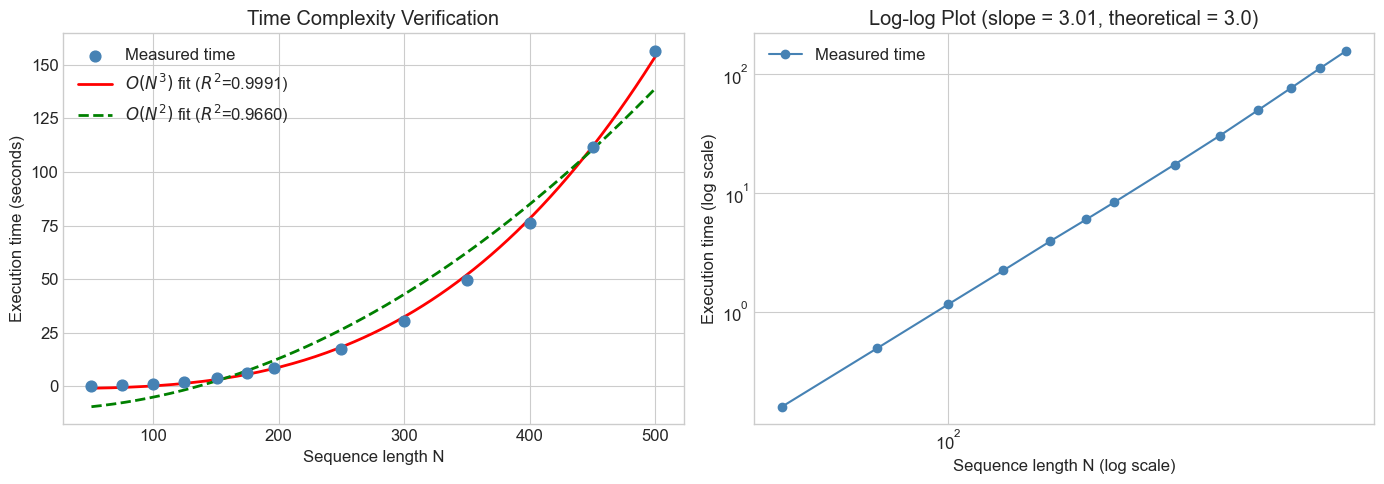

In [ ]:

def cubic_func(n, a, b):
    return a * n**3 + b

def quadratic_func(n, a, b):
    return a * n**2 + b


popt_time, _ = curve_fit(cubic_func, lengths, times)
fitted_times = cubic_func(lengths, *popt_time)

ss_res = np.sum((times - fitted_times) ** 2)
ss_tot = np.sum((times - np.mean(times)) ** 2)
r2_time = 1 - ss_res / ss_tot

popt_time_q, _ = curve_fit(quadratic_func, lengths, times)
fitted_times_q = quadratic_func(lengths, *popt_time_q)
ss_res_q = np.sum((times - fitted_times_q) ** 2)
r2_time_q = 1 - ss_res_q / ss_tot

print(f"Time complexity fitting results:")
print(f"  O(N^3) fit: T = {popt_time[0]:.2e} * N^3 + {popt_time[1]:.4f}, R² = {r2_time:.6f}")
print(f"  O(N^2) fit: T = {popt_time_q[0]:.2e} * N^2 + {popt_time_q[1]:.4f}, R² = {r2_time_q:.6f}")
print(f"  => O(N^3) fit is better than O(N^2), verifying time complexity is O(N^3)")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax = axes[0]
ax.scatter(lengths, times, color='steelblue', s=60, zorder=5, label='Measured time')
n_smooth = np.linspace(lengths.min(), lengths.max(), 200)
ax.plot(n_smooth, cubic_func(n_smooth, *popt_time), 'r-', linewidth=2,
        label=f'$O(N^3)$ fit ($R^2$={r2_time:.4f})')
ax.plot(n_smooth, quadratic_func(n_smooth, *popt_time_q), 'g--', linewidth=2,
        label=f'$O(N^2)$ fit ($R^2$={r2_time_q:.4f})')
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Execution time (seconds)')
ax.set_title('Time Complexity Verification')
ax.legend()

# Log-log scale
ax = axes[1]
ax.loglog(lengths, times, 'o-', color='steelblue', markersize=6, label='Measured time')
log_slope = np.polyfit(np.log(lengths), np.log(times), 1)[0]
ax.set_xlabel('Sequence length N (log scale)')
ax.set_ylabel('Execution time (log scale)')
ax.set_title(f'Log-log Plot (slope = {log_slope:.2f}, theoretical = 3.0)')
ax.legend()

plt.tight_layout()
plt.show()

### 7.2 Space Complexity Verification: $O(N^2)$

Space complexity fitting results:
  O(N^2) fit: M = 4.06e+00 * N^2 + 1.49e+05, R² = 0.999999
  O(N^3) fit: M = 8.13e-03 * N^3 + 2.24e+05, R² = 0.975492
  => O(N^2) fit is better, verifying space complexity is O(N^2)


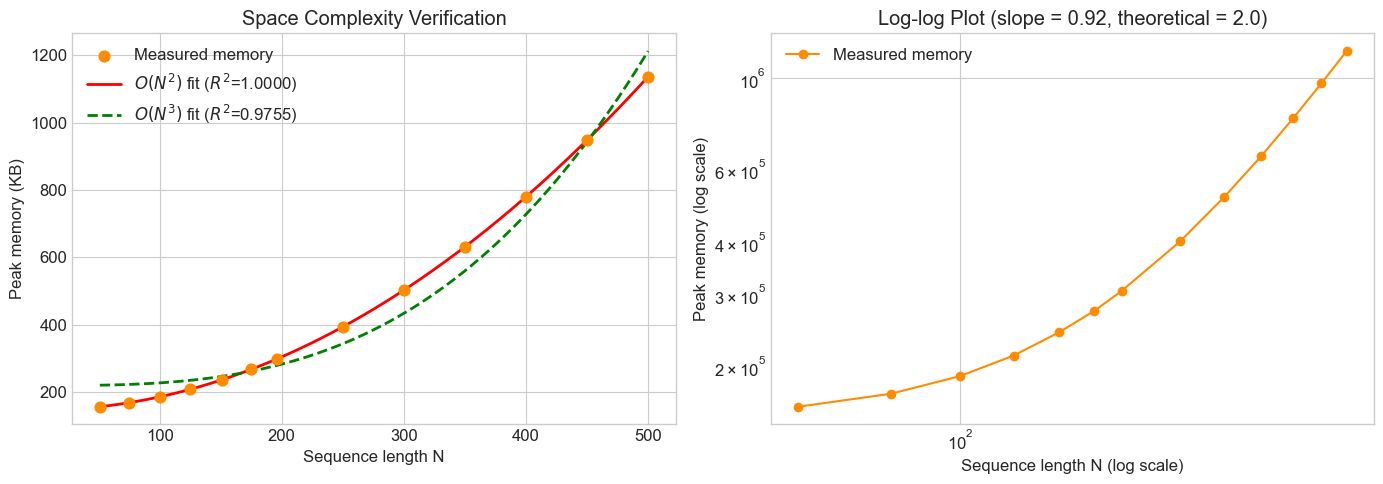

In [ ]:

popt_mem, _ = curve_fit(quadratic_func, lengths, memories)
fitted_mems = quadratic_func(lengths, *popt_mem)

ss_res_m = np.sum((memories - fitted_mems) ** 2)
ss_tot_m = np.sum((memories - np.mean(memories)) ** 2)
r2_mem = 1 - ss_res_m / ss_tot_m

popt_mem_c, _ = curve_fit(cubic_func, lengths, memories)
fitted_mems_c = cubic_func(lengths, *popt_mem_c)
ss_res_mc = np.sum((memories - fitted_mems_c) ** 2)
r2_mem_c = 1 - ss_res_mc / ss_tot_m

print(f"Space complexity fitting results:")
print(f"  O(N^2) fit: M = {popt_mem[0]:.2e} * N^2 + {popt_mem[1]:.2e}, R² = {r2_mem:.6f}")
print(f"  O(N^3) fit: M = {popt_mem_c[0]:.2e} * N^3 + {popt_mem_c[1]:.2e}, R² = {r2_mem_c:.6f}")
print(f"  => O(N^2) fit is better, verifying space complexity is O(N^2)")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(lengths, memories / 1024, color='darkorange', s=60, zorder=5, label='Measured memory')
ax.plot(n_smooth, quadratic_func(n_smooth, *popt_mem) / 1024, 'r-', linewidth=2,
        label=f'$O(N^2)$ fit ($R^2$={r2_mem:.4f})')
ax.plot(n_smooth, cubic_func(n_smooth, *popt_mem_c) / 1024, 'g--', linewidth=2,
        label=f'$O(N^3)$ fit ($R^2$={r2_mem_c:.4f})')
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Peak memory (KB)')
ax.set_title('Space Complexity Verification')
ax.legend()

ax = axes[1]
ax.loglog(lengths, memories, 'o-', color='darkorange', markersize=6, label='Measured memory')
log_slope_mem = np.polyfit(np.log(lengths), np.log(memories), 1)[0]
ax.set_xlabel('Sequence length N (log scale)')
ax.set_ylabel('Peak memory (log scale)')
ax.set_title(f'Log-log Plot (slope = {log_slope_mem:.2f}, theoretical = 2.0)')
ax.legend()

plt.tight_layout()
plt.show()